In [63]:
import openeo
import tempfile
import tifffile
import numpy as np
import os
# First, we connect to the back-end and authenticate. 
connection = openeo.connect("openeofed.dataspace.copernicus.eu")
connection.authenticate_oidc()

from pyproj import Transformer
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import datetime
import sys
sys.path.append('/home/michael/project_khthon')
from get_data_from_eo import *
from matplotlib import pyplot as plt
from lat_lon_parser import parse
sys.path.append('/home/michael/project_khthon/fmow')
from inference import *
def get_lat_lon(lat, lon):
    return parse(lat), parse(lon)

%load_ext autoreload
%autoreload 2
# coordinates of the Arcis-sur-Aube field
lat, lon = 13.623030555555555, 25.321508333333334
lon_min, lon_max = lon - 0.03, lon + 0.03
lat_min, lat_max = lat - 0.03, lat + 0.03
image2 = get_image(lat, lon, 1000, 1000, days = 10, time = datetime(2024, 6, 25).date())

Authenticated using refresh token.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
🛰️ Status: 0:00:00 Job 'cdse-j-26093000461441cbbfdcd34772044d61': send 'start' | Progress: 0 | Job ID: cdse-j-26093000461441cbbfdcd34772044d61
🛰️ Status: 0:00:13 Job 'cdse-j-26093000461441cbbfdcd34772044d61': queued (progress 0%) | Progress: 0 | Job ID: cdse-j-26093000461441cbbfdcd34772044d61
🛰️ Status: 0:00:19 Job 'cdse-j-26093000461441cbbfdcd34772044d61': queued (progress 0%) | Progress: 0 | Job ID: cdse-j-26093000461441cbbfdcd34772044d61
🛰️ Status: 0:00:26 Job 'cdse-j-26093000461441cbbfdcd34772044d61': queued (progress 0%) | Progress: 0 | Job ID: cdse-j-26093000461441cbbfdcd34772044d61
🛰️ Status: 0:00:35 Job 'cdse-j-26093000461441cbbfdcd34772044d61': queued (progress 0%) | Progress: 0 | Job ID: cdse-j-26093000461441cbbfdcd34772044d61
🛰️ Status: 0:00:46 Job 'cdse-j-26093000461441cbbfdcd34772044d61': queued (progress 0%) | Progress: 0 | Job ID: cdse-j-260930004614

/home/michael/project_khthon/get_data_from_eo.py:141: UserDeprecationWarning: Call to deprecated method download_results. (Instead use `BatchJob.get_results` and the more flexible download functionality of `JobResults`) -- Deprecated since version 0.4.10.
  image = job.download_results(download_dir)
/home/michael/project_khthon/khthon/lib/python3.12/site-packages/openeo/rest/job.py:199: UserDeprecationWarning: Call to deprecated method get_result. (Use `BatchJob.get_results` instead.) -- Deprecated since version 0.4.10.
  return self.get_result().download_files(target)
/home/michael/project_khthon/khthon/lib/python3.12/site-packages/openeo/rest/job.py:203: UserDeprecationWarning: Call to deprecated class _Result. (Use `JobResults` instead) -- Deprecated since version 0.4.10.
  return _Result(self)


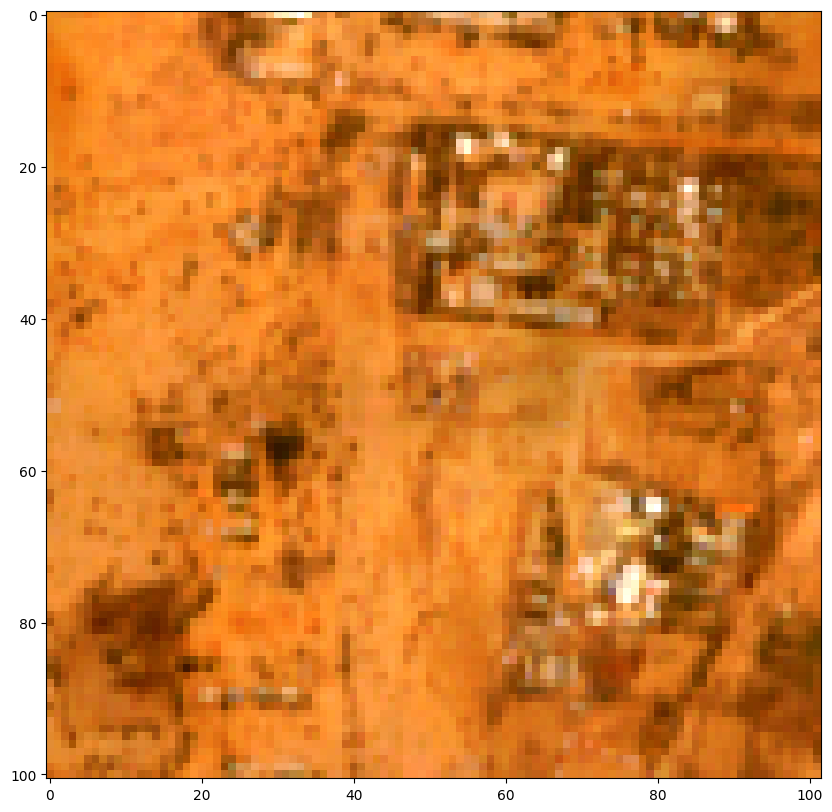

In [64]:
%matplotlib inline
fig = plt.figure()
fig.set_size_inches(10, 10)
plt.imshow(turn_into_image(image2))
plt.show()

  Cloning https://github.com/ESDS-Leipzig/cubo.git to /tmp/pip-req-build-5kj43fj7
  Running command git clone --filter=blob:none --quiet https://github.com/ESDS-Leipzig/cubo.git /tmp/pip-req-build-5kj43fj7
  Resolved https://github.com/ESDS-Leipzig/cubo.git to commit 1bf975e5d928b42db1a6fd742a4770c9ea3f0631
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 288.7 kB/s eta 0:00:000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 448.6 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 207.5 kB/s eta 0:00:000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 460.3 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 319.7 kB/s eta 0:00:00 0:00:01
  Created wheel for cubo: filename=cubo-2026.2.0-py3-none-any.whl size=11729 sha256=d1f192ff46d3caec16b8dcfd9fa24b2e1170ceaa5df18b025127c010865a82c6
  Stored in directory: /tmp/pip-ephem-wheel-cache-qm_wgci7/wheels/2f/70/b8/42eafd3e527bc4710ee557cdc1367b6f662818f2bf56b43726
Successfully built cubo
Note: you may need to restart the kernel to use updated packages.


torch.Size([4, 128, 128])


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 14.12it/s]


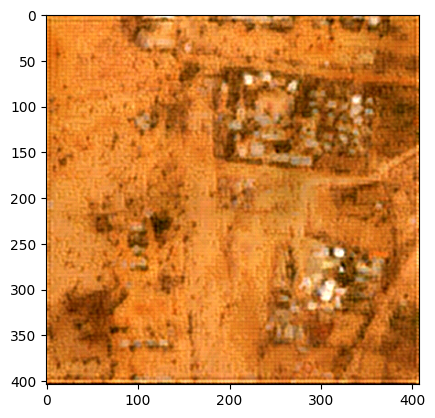

In [123]:
import mlstac
import torch
import numpy as np
import get_data_from_eo
from get_data_from_eo import *

rgb_image = to_2_5_m(image2, input_dir = "model/SENSRLite_RGBN")
plt.imshow(rgb_image)

In [4]:
import torch
from transformers import AutoImageProcessor, AutoModel
from transformers.image_utils import load_image

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = load_image(url)

pretrained_model_name = "facebook/dinov3-vit7b16-pretrain-sat493m"
processor = AutoImageProcessor.from_pretrained(pretrained_model_name)
model = AutoModel.from_pretrained(
    pretrained_model_name, 
    device_map="auto", 
)

inputs = processor(images=image, return_tensors="pt").to(model.device)
with torch.inference_mode():
    outputs = model(**inputs)

pooled_output = outputs.pooler_output
print("Pooled output shape:", pooled_output.shape)


ValueError: Using a `device_map`, `tp_plan`, `torch.device` context manager or setting `torch.set_default_device(device)` requires `accelerate`. You can install it with `pip install accelerate`

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from transformers import AutoImageProcessor, AutoModel
from transformers.image_utils import load_image

# 1. Load gated DINOv3 model & processor
# Ensure you are logged in via `huggingface-cli login` or HF_TOKEN env var
MODEL_ID = "facebook/dinov3-vitl16-pretrain-sat493m"  # or facebook/dinov3-vith16plus-pretrain-lvd1689m
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).eval()

# 2. Load and preprocess image
image = (turn_into_image(image2) * 255).astype(np.uint8)

patch_features = []
for x in range(0, image.shape[1], 224):
    for y in range(0, image.shape[0], 224):
        inputs = processor(images=image[y:y+224, x:x+224], return_tensors="pt")
        patch_size = model.config.patch_size  # Typically 16

        _, _, img_h, img_w = inputs.pixel_values.shape
        num_patches_h = img_h // patch_size
        num_patches_w = img_w // patch_size

        # 3. Extract dense patch embeddings
        with torch.inference_mode():
            outputs = model(**inputs)

        last_hidden_states = outputs.last_hidden_state  # [1, 1 + num_registers + num_patches, hidden_dim]

        # 4. Skip CLS (1) and Register Tokens (num_registers)
        num_registers = getattr(model.config, "num_register_tokens", 4)
        patch_tokens_flat = last_hidden_states[0, 1 + num_registers :, :]  # [num_patches, hidden_dim]

        # 5. Reshape to 2D Spatial Matrix
        # Shape: [H_patches, W_patches, hidden_dim] (e.g., [14, 14, 1024] for ViT-L on 224x224)
        feature_matrix_2d = patch_tokens_flat.reshape(h_patches, w_patches, -1)
print(len(patch_features))

NameError: name 'h_patches' is not defined

In [124]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.decomposition import PCA
from transformers import AutoImageProcessor, AutoModel

# 1. Load gated DINOv3 model & processor
MODEL_ID = "facebook/dinov3-vitl16-pretrain-sat493m"
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).eval()

patch_size = model.config.patch_size  # Typically 16
num_registers = getattr(model.config, "num_register_tokens", 4)
hidden_dim = model.config.hidden_size  # 1024 for ViT-L

# Convert input image to uint8 array if floating point
#rgb_image = turn_into_image(image2)
image = (rgb_image * 255).astype(np.uint8) if rgb_image.max() <= 1.0 else rgb_image.astype(np.uint8)
img_h, img_w = image.shape[:2]

# Determine tile steps and total patch grid dimensions
x_steps = list(range(0, img_w, 224))
y_steps = list(range(0, img_h, 224))

n_tiles_y = len(y_steps)
n_tiles_x = len(x_steps)

patches_per_tile_h = 224 // patch_size  # 14
patches_per_tile_w = 224 // patch_size  # 14

total_patches_h = n_tiles_y * patches_per_tile_h
total_patches_w = n_tiles_x * patches_per_tile_w

# Pre-allocate full spatial feature matrix: [Total_Patches_Y, Total_Patches_X, Hidden_Dim]
full_feature_matrix = np.zeros((total_patches_h, total_patches_w, hidden_dim), dtype=np.float32)

# 2. Extract features tile-by-tile and populate full feature matrix
for ty_idx, y in enumerate(tqdm(y_steps, desc="Processing Tiles")):
    for tx_idx, x in enumerate(x_steps):
        chip = image[y : y + 224, x : x + 224]

        # Handle boundary tiles: shift window to stay within image bounds
        # instead of padding with zeros
        if chip.shape[0] < 224 or chip.shape[1] < 224:
            y_start = min(y, max(img_h - 224, 0))
            x_start = min(x, max(img_w - 224, 0))
            chip = image[y_start:y_start+224, x_start:x_start+224]

        inputs = processor(images=chip, return_tensors="pt", do_normalize = False, do_rescale = True)

        with torch.inference_mode():
            outputs = model(**inputs)

        last_hidden_states = outputs.last_hidden_state  # [1, 1 + num_registers + num_patches, hidden_dim]

        # Skip CLS (1) and Register Tokens (num_registers)
        patch_tokens_flat = last_hidden_states[0, 1 + num_registers :, :]  # [196, 1024]

        # Reshape to 2D Spatial Patch Matrix per tile: [14, 14, 1024]
        feature_matrix_2d = patch_tokens_flat.reshape(patches_per_tile_h, patches_per_tile_w, -1).cpu().numpy()

        # Insert 14x14 block directly into full matrix coordinates
        row_start = ty_idx * patches_per_tile_h
        row_end = row_start + patches_per_tile_h
        col_start = tx_idx * patches_per_tile_w
        col_end = col_start + patches_per_tile_w

        full_feature_matrix[row_start:row_end, col_start:col_end, :] = feature_matrix_2d

print("Full Spatial Feature Matrix Shape:", full_feature_matrix.shape)
# Output shape: [ (img_h // 224) * 14, (img_w // 224) * 14, 1024 ]

# -------------------------------------------------------------------------
# 3. Apply Shared PCA and Reconstruct Map
# -------------------------------------------------------------------------

# Flatten spatial patch grid to 2D matrix for PCA: [Total_Patches, 1024]
all_patch_features = full_feature_matrix.reshape(-1, hidden_dim)

# Fit PCA
pca = PCA(n_components=3)
all_pca_features = pca.fit_transform(all_patch_features)

# Min-Max Normalization (0.0 to 1.0 RGB)
pca_min = all_pca_features.min(axis=0)
pca_max = all_pca_features.max(axis=0)
all_pca_rgb = (all_pca_features - pca_min) / (pca_max - pca_min + 1e-8)

# Reshape back to 2D spatial RGB patch map: [Total_Patches_Y, Total_Patches_X, 3]
pca_patch_map = all_pca_rgb.reshape(total_patches_h, total_patches_w, 3)

# Upsample patch map back to original pixel dimensions via nearest-neighbor
full_pca_stitched = np.kron(pca_patch_map, np.ones((patch_size, patch_size, 1)))

# Crop off padding if original image wasn't divisible by 224
full_pca_stitched = full_pca_stitched[:img_h, :img_w]

Processing Tiles: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.20s/it]

Full Spatial Feature Matrix Shape: (28, 28, 1024)


In [67]:
x = 2500
y = 2500
full_feature_matrix.shape

(28, 28, 1024)

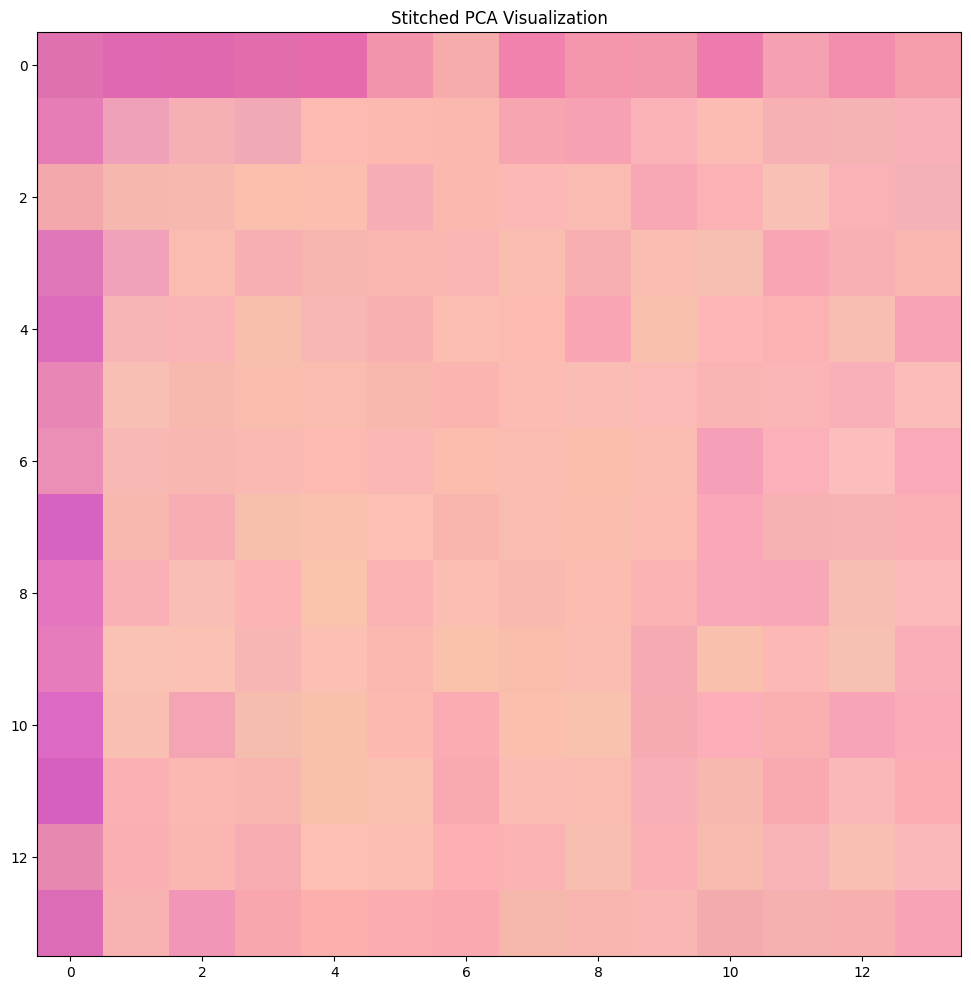

In [68]:

# Plot results
plt.figure(figsize=(12, 12))
plt.imshow(pca_patch_map[:img_h//224 * patches_per_tile_h, :img_w//224 * patches_per_tile_h])
plt.title("Stitched PCA Visualization")
#plt.axis("off")
plt.show()

In [125]:
def get_similarity_map(dino_vector_map, image, point):
    """
    Given a dino_vector_map, an image, and a point in image coordinates,
    find the corresponding vector in the dino_vector_map, dot product it with
    every other vector, upsample to original image size, and return.

    Parameters:
    -----------
    dino_vector_map : np.ndarray, shape (H_patches, W_patches, hidden_dim)
        The patch-level DINO feature map (e.g., full_feature_matrix)
    image : np.ndarray, shape (img_h, img_w, ...)
        The original image
    point : tuple (x, y)
        Point in image coordinates (x=column, y=row)

    Returns:
    --------
    similarity_map : np.ndarray, shape (img_h, img_w)
        Upsampled dot product similarity map
    """
    img_h, img_w = image.shape[:2]
    H_patches, W_patches = dino_vector_map.shape[:2]

    # Convert image coordinates to patch coordinates
    x, y = point
    patch_x = int(x * W_patches / img_w)
    patch_y = int(y * H_patches / img_h)

    # Clamp to valid range
    patch_x = min(max(patch_x, 0), W_patches - 1)
    patch_y = min(max(patch_y, 0), H_patches - 1)

    # Get the reference vector
    ref_vector = dino_vector_map[patch_y, patch_x]  # shape: (hidden_dim,)

    # Normalize vectors (L2) before dot product
    norms = np.linalg.norm(dino_vector_map, axis=-1, keepdims=True)
    normalized_map = dino_vector_map / (norms + 1e-8)

    ref_norm = np.linalg.norm(ref_vector)
    normalized_ref = ref_vector / (ref_norm + 1e-8)

    # Dot product with every other vector (cosine similarity)
    similarity_map = np.dot(normalized_map, normalized_ref)  # shape: (H_patches, W_patches)

    # Upsample to original image size using bicubic interpolation
    from scipy.ndimage import zoom

    zoom_y = img_h / H_patches
    zoom_x = img_w / W_patches
    upsampled = zoom(similarity_map, (zoom_y, zoom_x), order=3)

    # Ensure exact size match (zoom may produce off-by-one dimensions)
    upsampled = upsampled[:img_h, :img_w]

    return upsampled


# Example usage:
# similarity = get_similarity_map(full_feature_matrix, image, (2500, 2500))
# plt.imshow(similarity, cmap="hot")
# plt.colorbar()
# plt.show()


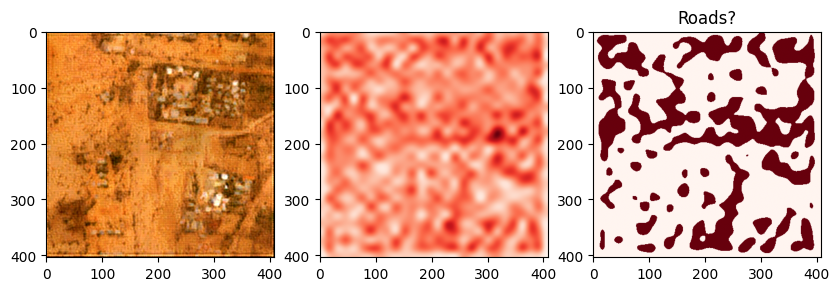

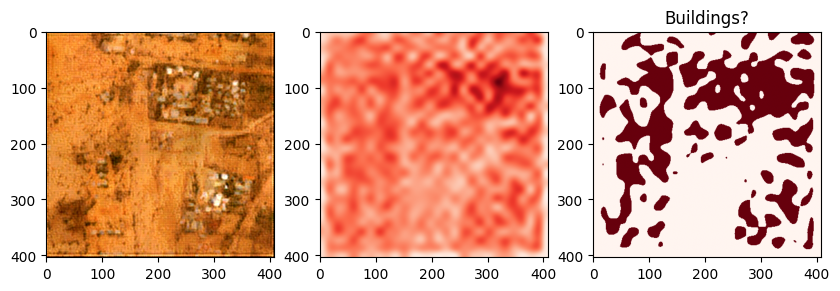

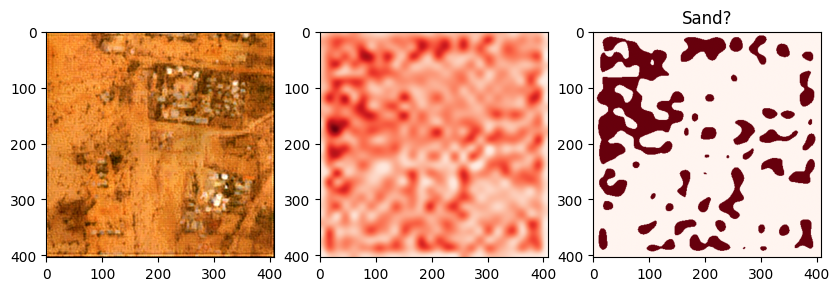

In [127]:
col = 80 * 4
row = 45 * 4
similarity_map = get_similarity_map(full_feature_matrix, image, (col, row))

fig, axs = plt.subplots(1, 3)
fig.set_size_inches(10, 10)
axs[0].imshow(image)
axs[1].imshow(similarity_map, cmap = 'Reds')
axs[2].set_title('Roads?')
axs[2].imshow(similarity_map > 0.6, cmap = 'Reds')
plt.show()

col = 80 * 4
row = 25 * 4
similarity_map = get_similarity_map(full_feature_matrix, image, (col, row))

fig, axs = plt.subplots(1, 3)
fig.set_size_inches(10, 10)
axs[0].imshow(image)
axs[1].imshow(similarity_map, cmap = 'Reds')
axs[2].set_title('Buildings?')
axs[2].imshow(similarity_map > 0.6, cmap = 'Reds')
plt.show()

col = 10 * 4
row = 45 * 4
similarity_map = get_similarity_map(full_feature_matrix, image, (col, row))

fig, axs = plt.subplots(1, 3)
fig.set_size_inches(10, 10)
axs[0].imshow(image)
axs[1].imshow(similarity_map, cmap = 'Reds')
axs[2].set_title('Sand?')
axs[2].imshow(similarity_map > 0.6, cmap = 'Reds')
plt.show()

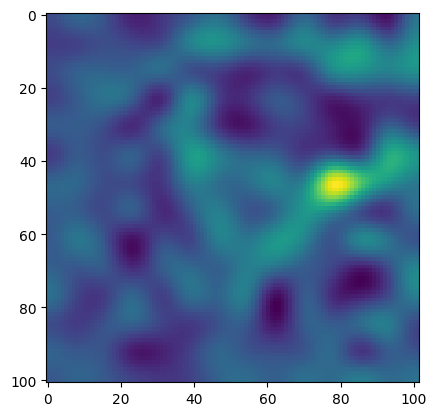

In [109]:
plt.imshow(similarity_map)
